In [2]:
"""
PROJECT 3: Image Classification with Transfer Learning (Computer Vision)
---------------------------------------------------------------------------
Goal: Classify CIFAR-10 images using a pretrained ResNet18 (transfer learning).
Dataset: CIFAR-10 (auto-downloaded via torchvision, ~170MB).

Run:
    pip install -r requirements.txt
    python 03_image_classification_transfer_learning.py
(Uses GPU automatically if available, otherwise CPU - CPU will be slower.)
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", DEVICE)

CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

BATCH_SIZE = 64
EPOCHS = 5          # increase for better accuracy once you confirm it runs
LR = 1e-3


def get_dataloaders():
    train_tf = transforms.Compose([
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    test_tf = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    train_set = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_tf)
    test_set = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_tf)

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return train_loader, test_loader


def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # Freeze base layers
    for param in model.parameters():
        param.requires_grad = False
    # Replace and unfreeze the final layer for our 10 classes
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)


def train_model(model, train_loader, test_loader):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=LR)

    history = {"train_loss": [], "test_acc": []}

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        acc = evaluate(model, test_loader, return_preds=False)
        history["train_loss"].append(epoch_loss)
        history["test_acc"].append(acc)
        print(f"Epoch {epoch+1}/{EPOCHS} - loss: {epoch_loss:.4f} - test_acc: {acc:.4f}")

    return history


def evaluate(model, loader, return_preds=True):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            if return_preds:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
    acc = correct / total
    if return_preds:
        return acc, all_preds, all_labels
    return acc


def plot_history(history):
    fig, ax1 = plt.subplots(figsize=(7, 5))
    ax1.plot(history["train_loss"], label="Train Loss", color="tab:red")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="tab:red")
    ax2 = ax1.twinx()
    ax2.plot(history["test_acc"], label="Test Accuracy", color="tab:blue")
    ax2.set_ylabel("Accuracy", color="tab:blue")
    plt.title("Training Loss and Test Accuracy")
    fig.tight_layout()
    plt.savefig("training_history.png")
    plt.close()


def main():
    train_loader, test_loader = get_dataloaders()
    model = build_model()
    history = train_model(model, train_loader, test_loader)
    plot_history(history)

    acc, preds, labels = evaluate(model, test_loader, return_preds=True)
    print(f"\nFinal test accuracy: {acc:.4f}")
    print(classification_report(labels, preds, target_names=CLASSES))

    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title("Confusion Matrix")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig("cv_confusion_matrix.png")
    plt.close()

    torch.save(model.state_dict(), "resnet18_cifar10.pth")
    print("\nSaved model weights to resnet18_cifar10.pth")
    print("Tip: for a nice CV addition, try Grad-CAM (pip install grad-cam) to visualize")
    print("which parts of an image the model focuses on.")


if __name__ == "__main__":
    main()




Using device: cuda
Epoch 1/5 - loss: 0.9560 - test_acc: 0.7800
Epoch 2/5 - loss: 0.7207 - test_acc: 0.7953
Epoch 3/5 - loss: 0.6945 - test_acc: 0.7932
Epoch 4/5 - loss: 0.6777 - test_acc: 0.7996
Epoch 5/5 - loss: 0.6621 - test_acc: 0.7981

Final test accuracy: 0.7981
              precision    recall  f1-score   support

    airplane       0.77      0.87      0.82      1000
  automobile       0.81      0.92      0.86      1000
        bird       0.79      0.72      0.76      1000
         cat       0.76      0.63      0.69      1000
        deer       0.74      0.75      0.74      1000
         dog       0.70      0.81      0.75      1000
        frog       0.81      0.85      0.83      1000
       horse       0.86      0.77      0.81      1000
        ship       0.94      0.78      0.85      1000
       truck       0.83      0.88      0.85      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80     

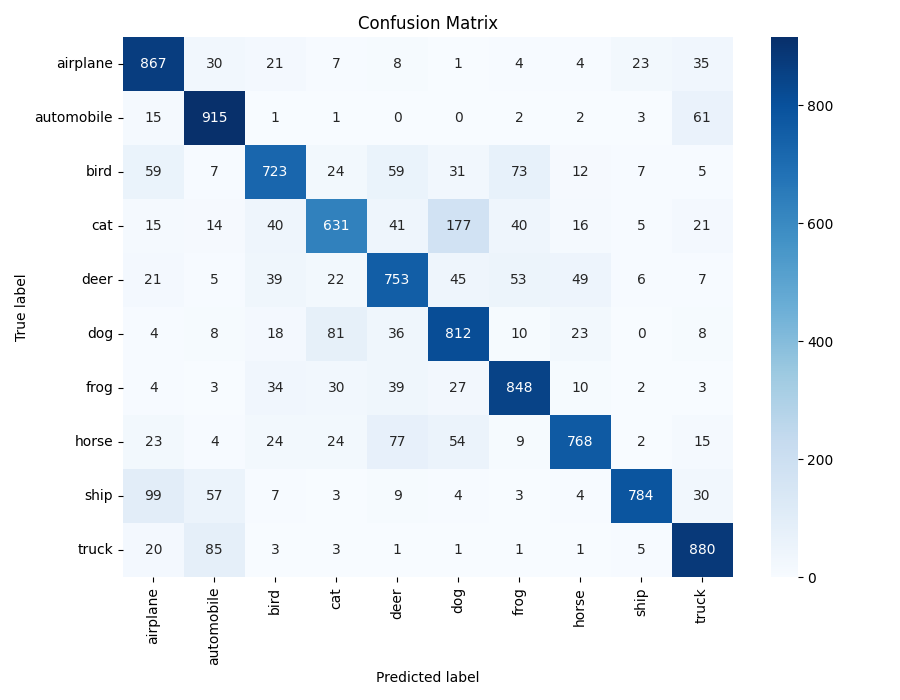

In [3]:
from IPython.display import Image, display

display(Image("cv_confusion_matrix.png"))